Author:  
Carlos Alberto Yánez Rubio

# Clasificación de Imágenes de estudiantes y fondos con VGG-16

En este Jupyter Notebook, vamos a desarrollar un clasificador de imágenes utilizando la arquitectura de red neuronal convolucional (CNN) conocida como VGG-16.

El objetivo es distinguir entre imágenes de un estudiante y fondos. Para ello, utilizaremos dos carpetas de datos con etiquetas binarias:
- `1`: estudiante
- `0`: fondo

VGG-16 es una arquitectura de CNN propuesta por K. Simonyan y A. Zisserman en el paper "Very Deep Convolutional Networks for Large-Scale Image Recognition". A partir de este modelo preentrenado, aplicaremos transfer learning para entrenar de forma más rápida y estable en nuestro problema.

Primero, vamos a importar las bibliotecas necesarias:

In [ ]:
%pip install ipykernel
%pip install opencv-python
%pip install keras
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB 1.3 MB/s eta 0:00:31
   ---------------------------------------- 0.2/40.2 MB 1.3 MB/s eta 0:00:31
   ---------------------------------------- 0.2/40.2 MB 1.3 MB/s eta 0:00:31
   ---------------------------------------- 0.3/40.2 MB 1.5 MB/s eta 0:00:28
   ---------------------------------------- 0.3/40.2 MB 1.5 MB/s eta 0:00:28
   ---------------------------------------- 0.3/40.2 MB 1.5 MB/s eta 0:00:28
   ---------------------------------------- 0.4/40.2 MB 1.2 MB/s eta 0:00:33
   ---------------------------------------- 0.5/40.2 MB 1.3 MB/s eta 0:00:31
    --------------------------------------- 0.6/40.2 MB 1.6 MB/s eta 0:00:26
    --------------------------------------- 0.6/40.2 MB 1.6 MB/s eta 0:00:26
    --------------------------------------- 0.6/40.2 MB 1.6 MB/s eta 0:00:26
    ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached keras-3.13.2-py3-none-any.whl (1.5 MB)
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
    --------------------------------------- 0.1/3.2 MB 1.7 MB/s eta 0:00:02
   - -------------------------------------- 0.1/3.2 MB 1.7 MB/s eta 0:00:02
   -- ------------------------------------- 0.2/3.2 MB 2.1 MB/s eta 0:00:02
   ---- ----------------------------------- 0.4/3.2 MB 2.4 MB/s eta 0:00:02
   ----- ---------------------------------- 0.4/3.2 MB 2.3 MB/s eta 0:00:02
   -------- ------------------------------- 0.7/3.2 MB 2.7 M

...


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
     ---------------------------------------- 0.0/41.4 kB ? eta -:--:--
     ---------------------------------------- 41.4/41.4 kB 2.1 MB/s eta 0:00:00
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/350.8 MB 1.7 MB/s eta 0:03:33
   ---------------------------------------- 0.3/350.8 MB 3.2 MB/s eta 0:01:52
   ---------------------------------------- 0.3/350.8 MB 3.2 MB/s eta 0:01:52
   ---------------------------------------- 0.5/350.8 MB 3.0 MB/s eta 0:01:59
   ---------------------------------------- 0.8/350.8 MB 3.4 MB/s eta 0:01:43
   ---------------------------------------- 1.4/350.8 MB 5.1 MB/s eta 0:01:08
   ---------------------------------------- 1.9/350

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     --------------- ------------------------ 20.5/52.8 kB ? eta -:--:--
     -------------------------------------- 52.8/52.8 kB 906.2 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ----------------------- --------------- 71.7/119.8 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.8 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.2/8.1 MB 9.6 MB/s eta 0:00:01
   -- ------------------------------------- 0.4/8.1 MB 5.5 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/8.1 MB 4.6 MB/s eta 0:00:02
   ----- ----------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

SEED = 42
np.random.seed(SEED)

Cargamos las imágenes de estudiante y fondo:

In [37]:
def get_face_detector():
    return cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


def crop_largest_face(img, face_detector, min_size=(50, 50), margin=0.15):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=min_size,
    )

    if len(faces) == 0:
        return None

    # Elegimos el rostro más grande para enfocarnos en rasgos principales
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    mx = int(w * margin)
    my = int(h * margin)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(img.shape[1], x + w + mx)
    y2 = min(img.shape[0], y + h + my)

    return img[y1:y2, x1:x2]


def load_images_from_folder(folder: Path, label: int, face_detector, image_size=(224, 224), use_face_crop=True):
    images = []
    labels = []

    for filename in os.listdir(folder):
        image_path = folder / filename
        img = cv2.imread(str(image_path))

        if img is None:
            continue

        # Para aprender rasgos faciales, priorizamos crop de rostro en clase estudiante
        if use_face_crop:
            face_img = crop_largest_face(img, face_detector)
            if face_img is None:
                continue
            img = face_img

        img = cv2.resize(img, image_size)
        img = preprocess_input(img.astype(np.float32))

        images.append(img)
        labels.append(label)

    return images, labels

face_detector = get_face_detector()

dataset_dir = Path.cwd().parent / "dataset"
student_dir = dataset_dir / "student"
background_dir = dataset_dir / "background"

if not student_dir.exists() or not background_dir.exists():
    raise FileNotFoundError(f"No se encontraron carpetas esperadas en: {dataset_dir}")

# Student: entrenamos con rostro detectado
student_images, student_labels = load_images_from_folder(
    student_dir,
    label=1,
    face_detector=face_detector,
    use_face_crop=True,
)

# Background: mantenemos imagen completa (sin rostro forzado)
background_images, background_labels = load_images_from_folder(
    background_dir,
    label=0,
    face_detector=face_detector,
    use_face_crop=False,
)

images = np.array(student_images + background_images, dtype=np.float32)
labels = np.array(student_labels + background_labels, dtype=np.float32)

print(f"Total imágenes válidas: {len(images)}")
print(f"Student: {int(np.sum(labels == 1))}, Background: {int(np.sum(labels == 0))}")

Total imágenes válidas: 28
Student: 14, Background: 14


In [38]:
# Revisamos dimensiones y balance de clases
print("Shape images:", images.shape)
print("Shape labels:", labels.shape)
print("Total Student:", int(np.sum(labels == 1)))
print("Total Background:", int(np.sum(labels == 0)))

Shape images: (28, 224, 224, 3)
Shape labels: (28,)
Total Student: 14
Total Background: 14


Dividmos los datos en conjuntos de entrenamiento y prueba:

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (22, 224, 224, 3) (22,)
Test: (6, 224, 224, 3) (6,)


Construimos y entrenamos la red neuronal convolucional VGG-16:

In [40]:
def build_model():
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.4),
        Dense(1, activation="sigmoid"),
    ])
    return model


# Configuración de pruebas de hiperparámetros
# Puedes añadir o quitar valores para explorar más combinaciones
hyperparam_grid = [
    {
        "name": "exp_1",
        "loss": "binary_crossentropy",
        "optimizer": Adam(learning_rate=1e-3),
        "epochs": 20,
        "batch_size": 16,
    },
    {
        "name": "exp_2",
        "loss": "binary_crossentropy",
        "optimizer": RMSprop(learning_rate=1e-4),
        "epochs": 30,
        "batch_size": 16,
    },
    {
        "name": "exp_3",
        "loss": "binary_crossentropy",
        "optimizer": SGD(learning_rate=1e-3, momentum=0.9),
        "epochs": 35,
        "batch_size": 32,
    },
]

results = []
best_model = None
best_history = None
best_val_acc = -1.0
best_config = None

for cfg in hyperparam_grid:
    print(f"\n--- Ejecutando {cfg['name']} ---")
    print(cfg)

    model = build_model()
    model.compile(loss=cfg["loss"], optimizer=cfg["optimizer"], metrics=["accuracy"])

    early_stopping = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6)

    train_datagen = ImageDataGenerator(
        rotation_range=12,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.12,
        horizontal_flip=True,
    )

    history = model.fit(
        train_datagen.flow(X_train, y_train, batch_size=cfg["batch_size"], shuffle=True),
        validation_data=(X_test, y_test),
        epochs=cfg["epochs"],
        callbacks=[early_stopping, reduce_lr],
        verbose=1,
    )

    val_acc = float(max(history.history["val_accuracy"]))
    val_loss = float(min(history.history["val_loss"]))

    results.append({
        "name": cfg["name"],
        "loss": cfg["loss"],
        "optimizer": cfg["optimizer"].__class__.__name__,
        "epochs": cfg["epochs"],
        "batch_size": cfg["batch_size"],
        "best_val_accuracy": val_acc,
        "best_val_loss": val_loss,
    })

    print(f"Mejor val_accuracy: {val_acc:.4f} | Mejor val_loss: {val_loss:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_history = history
        best_config = cfg

# Dejamos el mejor modelo como 'model' para las celdas siguientes
model = best_model
history = best_history

print("\n=== Mejor configuración ===")
print(best_config)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss (test): {loss:.4f}")
print(f"Accuracy (test): {accuracy:.4f}")

for row in results:
    print(row)


--- Ejecutando exp_1 ---
{'name': 'exp_1', 'loss': 'binary_crossentropy', 'optimizer': <keras.src.optimizers.adam.Adam object at 0x000001D5D983D750>, 'epochs': 20, 'batch_size': 16}
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5455 - loss: 4.0556 - val_accuracy: 0.5000 - val_loss: 1.9803 - learning_rate: 0.0010
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8182 - loss: 1.0511 - val_accuracy: 0.8333 - val_loss: 1.4930 - learning_rate: 0.0010
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 842ms/step - accuracy: 0.8636 - loss: 1.3952 - val_accuracy: 0.8333 - val_loss: 1.7353 - learning_rate: 0.0010
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8182 - loss: 0.7490 - val_accuracy: 0.8333 - val_loss: 1.6330 - learning_rate: 0.0010
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9545 - loss: 0.2040 - val_accuracy: 0.8333 - val_loss: 1.5988 - learning_rate: 2.0000e-04
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9545 - loss: 0

**Opcional:** Guardamos el modelo en un archivo formato .h5 y lo cargamos en el dispositivo de despliegue

In [41]:
# Guardamos el modelo en formato moderno de Keras
model.save("classification_model_student_background.keras")

In [42]:
model = load_model("classification_model_student_background.keras")

Hacemos una predicción con una nueva imagen para comprobar que el modelo funciona

In [43]:
# Predicción usando rostro detectado para enfocarse en rasgos faciales
img = cv2.imread('C:\\Users\\cyanezru\\OneDrive - NTT DATA EMEAL\\Documentos\\Repositories\\Vision-por-computador-MIA-B---Grupo-3\\Clase_2\\dataset\\000016.jpg')

if img is None:
    raise FileNotFoundError("No se pudo leer la imagen de prueba")

face_img = crop_largest_face(img, face_detector)
if face_img is None:
    raise ValueError("No se detectó rostro en la imagen de prueba")

face_resized = cv2.resize(face_img, (224, 224))
face_input = preprocess_input(face_resized.astype(np.float32))
face_input = np.expand_dims(face_input, axis=0)

pred_score = float(model.predict(face_input, verbose=0)[0][0])
pred_label = "Student" if pred_score >= 0.5 else "Background"

print(f"Score Student: {pred_score:.4f}")
print(f"Predicción: {pred_label}")

Score Student: 0.9568
Predicción: Student


Aunque se evalúe una sola imagen, el modelo siempre recibe y devuelve lotes (batches).

- `pred_score >= 0.5` indica clase `Student`
- `pred_score < 0.5` indica clase `Background`

Este umbral puede ajustarse si quieres priorizar precisión o recall para la clase estudiante.

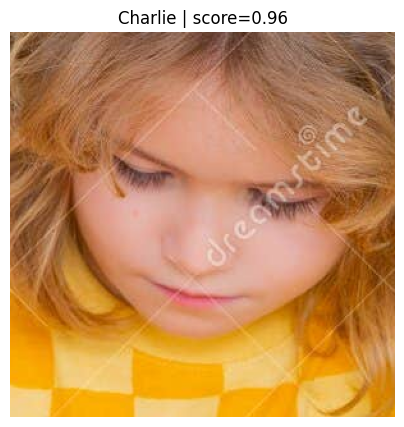

In [44]:
img = cv2.imread('C:\\Users\\cyanezru\\OneDrive - NTT DATA EMEAL\\Documentos\\Repositories\\Vision-por-computador-MIA-B---Grupo-3\\Clase_2\\dataset\\000016.jpg')

if img is None:
    raise FileNotFoundError("No se pudo leer la imagen de prueba")

face_img = crop_largest_face(img, face_detector)
if face_img is None:
    raise ValueError("No se detectó rostro en la imagen")

face_resized = cv2.resize(face_img, (224, 224))
face_input = preprocess_input(face_resized.astype(np.float32))
face_input = np.expand_dims(face_input, axis=0)

pred_score = float(model.predict(face_input, verbose=0)[0][0])
label = "Charlie" if pred_score >= 0.5 else "Background"

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
plt.title(f"{label} | score={pred_score:.2f}")
plt.axis('off')
plt.show()

## Actividad individual calificable:

En esta actividad, llevaremos a cabo una serie de pruebas para evaluar la capacidad de nuestro modelo de clasificación de imágenes. El objetivo es identificar correctamente si una imagen contiene el rostro de un estudiante específico o si pertenece a un fondo. Para ello, hemos definido dos etiquetas principales:

##### **Label 1:** `Nombre del estudiante`  
##### **Label 2:** `Fondo` (imagenes que no contengan el rostro del estudiante)

#### **Pruebas:**

Las pruebas se realizarán con diferentes tipos de imágenes de entrada para verificar la precisión del modelo en escenarios no vistos durante el entrenamiento:

1. **Input image:** Foto del estudiante que no se encuentre en la carpeta de entrenamiento (tómate una foto el día de la presentación usando tu webcam).
**Required output label:** `Nombre del estudiante`

2. **Input image:** Fondo que no se encuentre en la carpeta de entrenamiento (el estudiante que presente antes de ti te dará la palabra de búsqueda, puedes descargarla de Google Images).  
**Required output label:** `Fondo`
3. **Input image:** Foto de un rostro diferente al rostro del estudiante que no se encuentre en las carpetas de entrenamiento (el estudiante que presente antes de ti te dará un nombre de una celebridad que se parezca a ti, puedes descargarla de Google Images).  
**Required output label:** `Fondo`

##### **Hyperparameter testing (Opcional):**

Además, puedes explorar el impacto de varios hiperparámetros en el rendimiento del modelo. Los hiperparámetros a ajustar incluyen:

-Aumento de imágenes en la base de datos  
-Cambio de función de pérdida (loss)  
-Cambio en el optimizador (optimizer)  
-Cambio en el número de épocas de entrenamiento (epochs)  
-Cambio en el número de tamaño de lote (batch_size)

Estas pruebas y ajustes te permitirán optimizar el modelo para obtener la mejor precisión posible en la clasificación de imágenes.

##### **Presentación de resultados**

Los estudiantes presentarán sus resultados en clase usando una app de `streamlit`. La calificación dependerá del éxito de las 3 pruebas.